# ERCOT Synthetic Weather Benchmark

A real-world-inspired benchmark dataset for causal discovery on nonstationary multivariate time series.
Generates 6-hourly **wind speed** (m/s) and **cloud cover** (%) for **8 diverse ERCOT Texas stations** over one year.

**Model:**
- Wind: Weibull(k=2) marginals with time-varying scale driven by a log-normal VAR(2) — captures diurnal/seasonal patterns, south-to-north spatial lag dependencies, and correct right-skewed marginals
- Cloud: logit-space AR(1) with contemporaneous negative wind coupling (windier → marginally clearer)
- Solar generation: TOA irradiance (analytical, physics-based) attenuated by cloud cover → GHI → MW
- Wind generation: standard cubic power curve → capacity factor → MW

**Causal ground truth (38 edges):**
- Wind self-AR at lag 1 and 2 (all stations)
- Cloud self-AR at lag 1
- 6 spatial wind→wind edges at lag 1 (south-to-north: KCRP→KIAH→KDFW→KSPS, KAMA→KSPS, KELP→KMAF, KMAF→KABI)
- Same-station wind→cloud at lag 0 (contemporaneous)

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from causalts.synthetic_data.weather_datasets import ercot_weather, STATIONS, STATION_META

## 1. Generate Data

In [2]:
result = ercot_weather(seed=42)
df = result['df']
ground_truth = result['ground_truth']
var_names = result['var_names']
wind_mwh = result['generation']['wind_mwh']
solar_mwh = result['generation']['solar_mwh']

print(f'Dataset: {len(var_names)} variables, {len(df)} timesteps (6-hourly), index: {df.index[0]} to {df.index[-1]}')
print(f'Variables: {var_names}')
print(f'Ground truth edges: {ground_truth.sum()}')
print(f'\nWind generation: mean={wind_mwh.mean():.0f} MWh, std={wind_mwh.std():.0f} MWh')
print(f'Solar generation: mean={solar_mwh.mean():.0f} MWh, peak={solar_mwh.max():.0f} MWh')

print('\nPer-station summary:')
print(f'{"Station":<8} {"Wind mean":>12} {"Wind std":>10} {"Cloud mean":>12}')
print('-' * 46)
for s in STATIONS:
    wm = df[f'{s}_wind'].mean()
    ws = df[f'{s}_wind'].std()
    cm = df[f'{s}_cloud'].mean()
    print(f'{s:<8} {wm:>11.2f}  {ws:>9.2f}  {cm:>11.1f}%')

Dataset: 16 variables, 1460 timesteps (6-hourly), index: 2023-01-01 00:00:00+00:00 to 2023-12-31 18:00:00+00:00
Variables: ['kcrp_wind', 'kcrp_cloud', 'kdfw_wind', 'kdfw_cloud', 'kelp_wind', 'kelp_cloud', 'kama_wind', 'kama_cloud', 'kiah_wind', 'kiah_cloud', 'kabi_wind', 'kabi_cloud', 'ksps_wind', 'ksps_cloud', 'kmaf_wind', 'kmaf_cloud']
Ground truth edges: 38

Wind generation: mean=11200 MWh, std=10192 MWh
Solar generation: mean=6017 MWh, peak=18820 MWh

Per-station summary:
Station     Wind mean   Wind std   Cloud mean
----------------------------------------------
kcrp            5.10       4.90         42.7%
kdfw            4.92       4.55         38.9%
kelp            3.68       3.96         28.5%
kama            5.53       5.07         35.7%
kiah            3.30       3.38         45.1%
kabi            4.73       4.29         36.2%
ksps            4.57       4.27         37.0%
kmaf            5.01       4.88         34.0%


## 2. Time Series Visualization

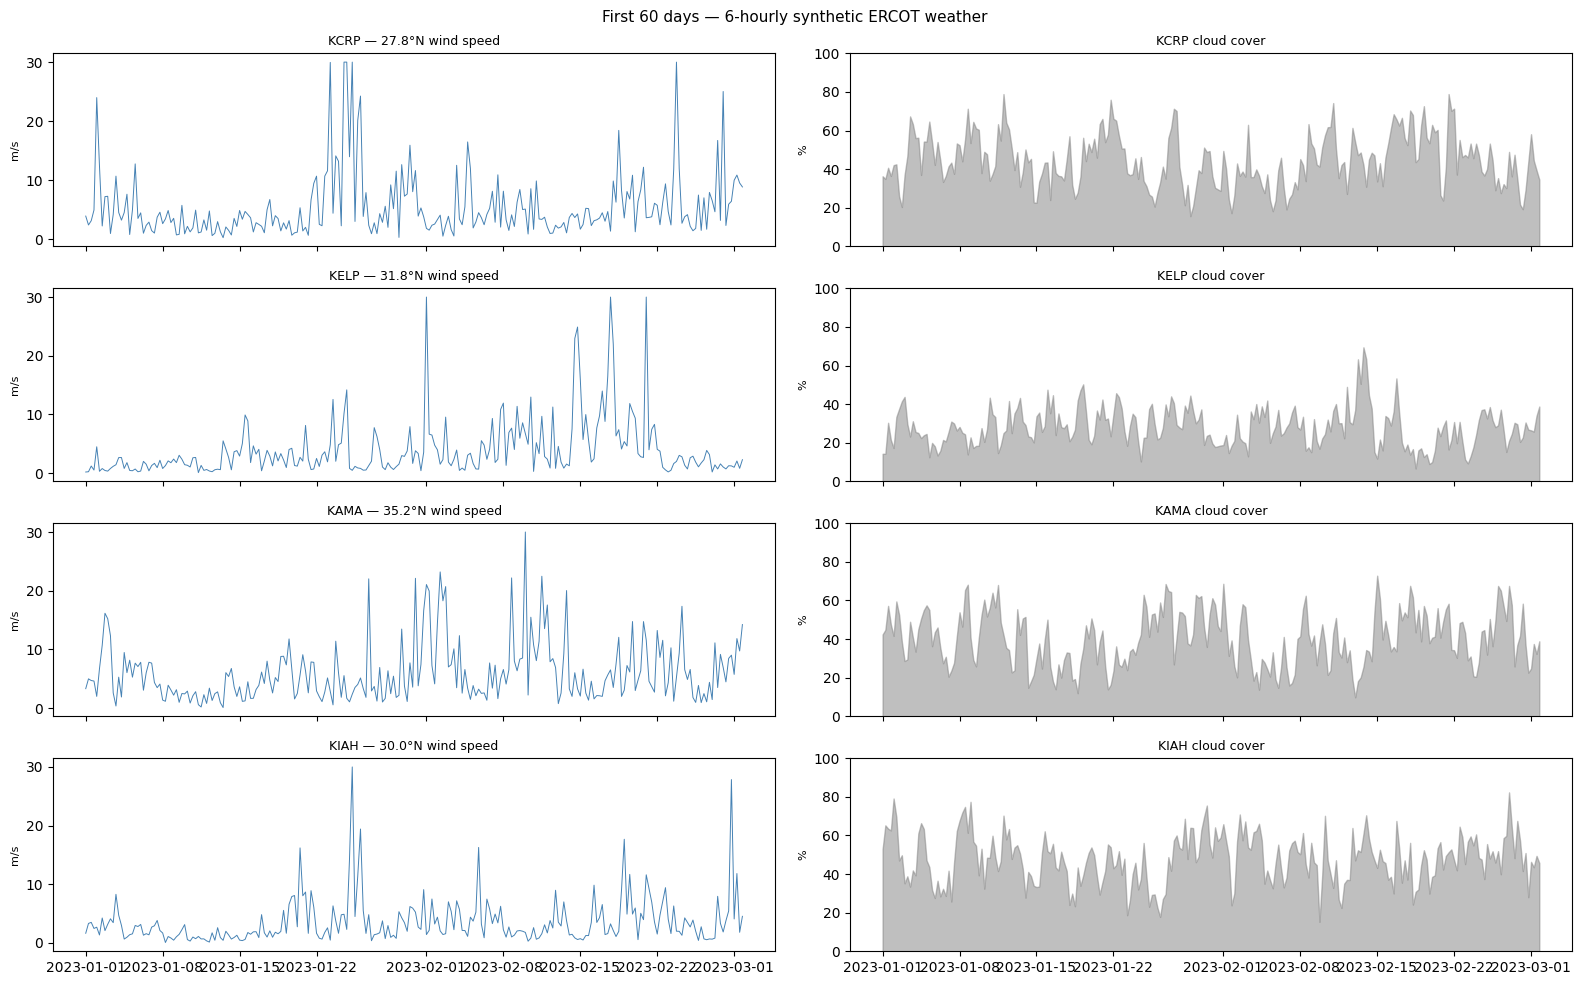

In [3]:
# Show first 60 days for 4 diverse stations
show_days = 60
show_steps = show_days * 4  # 4 steps/day at 6h
selected = ['kcrp', 'kelp', 'kama', 'kiah']

fig, axes = plt.subplots(len(selected), 2, figsize=(16, 10), sharex=True)
for idx, s in enumerate(selected):
    t = df.index[:show_steps]
    ax_w, ax_c = axes[idx, 0], axes[idx, 1]
    ax_w.plot(t, df[f'{s}_wind'].values[:show_steps], lw=0.7, color='steelblue')
    ax_w.set_ylabel('m/s', fontsize=8)
    ax_w.set_title(f'{s.upper()} — {STATION_META[s]["lat"]:.1f}°N wind speed', fontsize=9)
    ax_c.fill_between(t, df[f'{s}_cloud'].values[:show_steps], alpha=0.5, color='gray')
    ax_c.set_ylim(0, 100)
    ax_c.set_ylabel('%', fontsize=8)
    ax_c.set_title(f'{s.upper()} cloud cover', fontsize=9)

plt.suptitle(f'First {show_days} days — 6-hourly synthetic ERCOT weather', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Diurnal and Seasonal Patterns

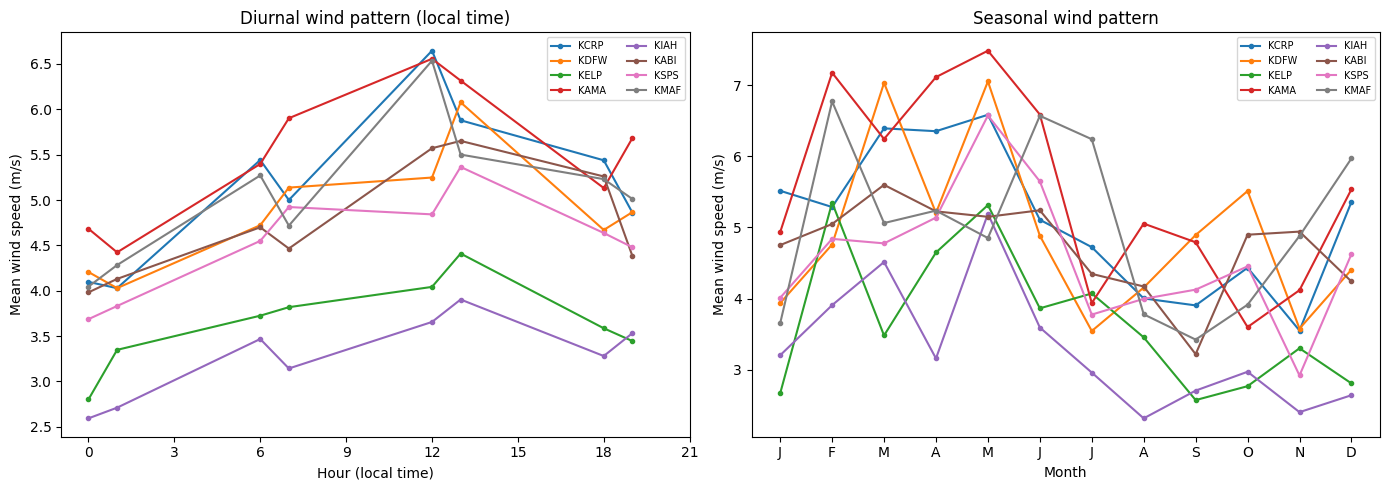

In [4]:
# Use Texas local time (UTC-6) for display
df_local = df.copy()
df_local.index = df.index.tz_convert('US/Central')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diurnal by station
ax = axes[0]
for s in STATIONS:
    hourly = df_local[f'{s}_wind'].groupby(df_local.index.hour).mean()
    ax.plot(hourly.index, hourly.values, marker='o', ms=3, label=s.upper())
ax.set_xlabel('Hour (local time)')
ax.set_ylabel('Mean wind speed (m/s)')
ax.set_title('Diurnal wind pattern (local time)')
ax.legend(fontsize=7, ncol=2)
ax.set_xticks(range(0, 24, 3))

# Seasonal by station
ax = axes[1]
for s in STATIONS:
    monthly = df_local[f'{s}_wind'].groupby(df_local.index.month).mean()
    ax.plot(monthly.index, monthly.values, marker='o', ms=3, label=s.upper())
ax.set_xlabel('Month')
ax.set_ylabel('Mean wind speed (m/s)')
ax.set_title('Seasonal wind pattern')
ax.legend(fontsize=7, ncol=2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

plt.tight_layout()
plt.show()

## 4. Wind Speed Marginal Distributions

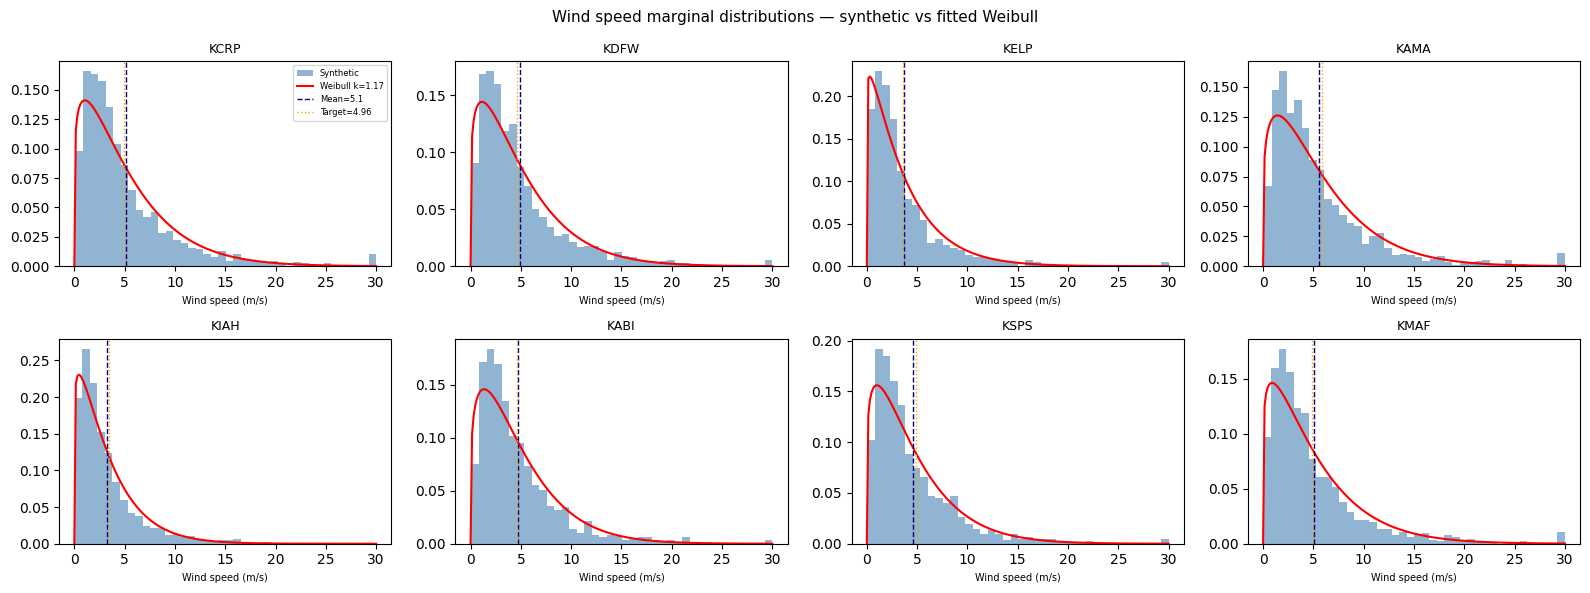

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for idx, s in enumerate(STATIONS):
    ax = axes[idx // 4, idx % 4]
    w = df[f'{s}_wind'].values
    ax.hist(w, bins=40, density=True, alpha=0.6, color='steelblue', label='Synthetic')

    # Fit Weibull to marginal
    k, loc, scale = stats.weibull_min.fit(w, floc=0)
    x = np.linspace(0, w.max(), 200)
    ax.plot(x, stats.weibull_min.pdf(x, k, 0, scale), 'r-', lw=1.5,
            label=f'Weibull k={k:.2f}')

    tgt_mean = STATION_META[s]['wind_mean']
    ax.axvline(w.mean(), color='navy', lw=1, ls='--', label=f'Mean={w.mean():.1f}')
    ax.axvline(tgt_mean, color='orange', lw=1, ls=':', label=f'Target={tgt_mean}')
    ax.set_title(f'{s.upper()}', fontsize=9)
    ax.set_xlabel('Wind speed (m/s)', fontsize=7)
    if idx == 0:
        ax.legend(fontsize=6)

plt.suptitle('Wind speed marginal distributions — synthetic vs fitted Weibull', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Cross-Station Correlation vs Ground Truth

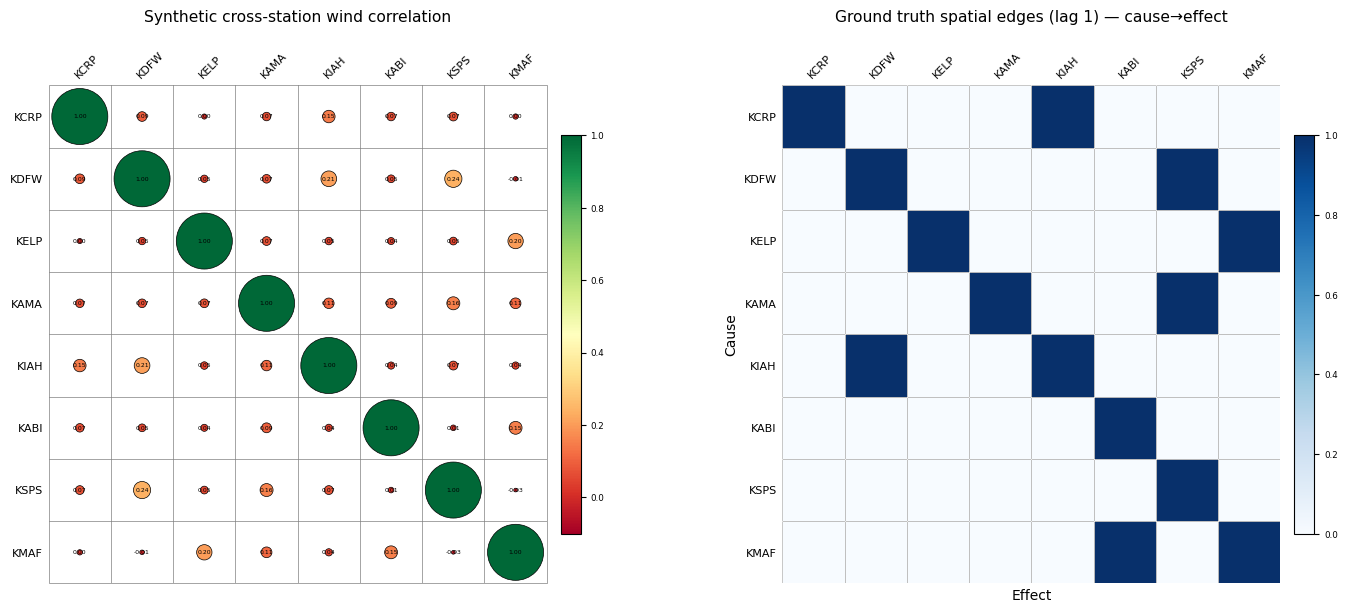

In [6]:
from causalts.plotting import corrplot

wind_cols = [f'{s}_wind' for s in STATIONS]
corr = df[wind_cols].corr()

# Ground truth spatial wind edges (lag 1)
gt_wind = ground_truth[::2, ::2, 1]  # wind-only, lag-1 slice

labels = [s.upper() for s in STATIONS]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: cross-station wind correlation. Circle area encodes |r| on top of the
# same RdYlGn scale the raw heatmap used.
corrplot(
    corr.rename(index=dict(zip(wind_cols, labels)),
                columns=dict(zip(wind_cols, labels))),
    method='circle',
    is_corr=False, cmap='RdYlGn', vmin=-0.1, vmax=1.0,
    diag='glyph',
    add_coef=True, number_fmt='.2f', number_cex=0.55,
    tl_cex=0.8, cl_cex=0.7,
    title='Synthetic cross-station wind correlation',
    fig_ax=(fig, axes[0]),
)

# Right: ground-truth adjacency. Directed (cause -> effect) and therefore
# asymmetric, so it is passed as a *labelled DataFrame* — corrplot only
# auto-detects a bare ndarray as precomputed when it is symmetric, and an
# asymmetric one would be mistaken for raw observations. 'color' is used
# instead of 'circle' because glyph area would encode nothing at 0/1, and
# diag='glyph' keeps the self-AR diagonal on the same colour scale.
corrplot(
    pd.DataFrame(gt_wind, index=labels, columns=labels),
    method='color',
    is_corr=False, cmap='Blues', vmin=0.0, vmax=1.0,
    diag='glyph',
    tl_cex=0.8, cl_cex=0.7,
    title='Ground truth spatial edges (lag 1) — cause→effect',
    fig_ax=(fig, axes[1]),
)
axes[1].set_xlabel('Effect')
axes[1].set_ylabel('Cause')

plt.tight_layout()
plt.show()

## 6. Solar Generation: TOA and Cloud Attenuation

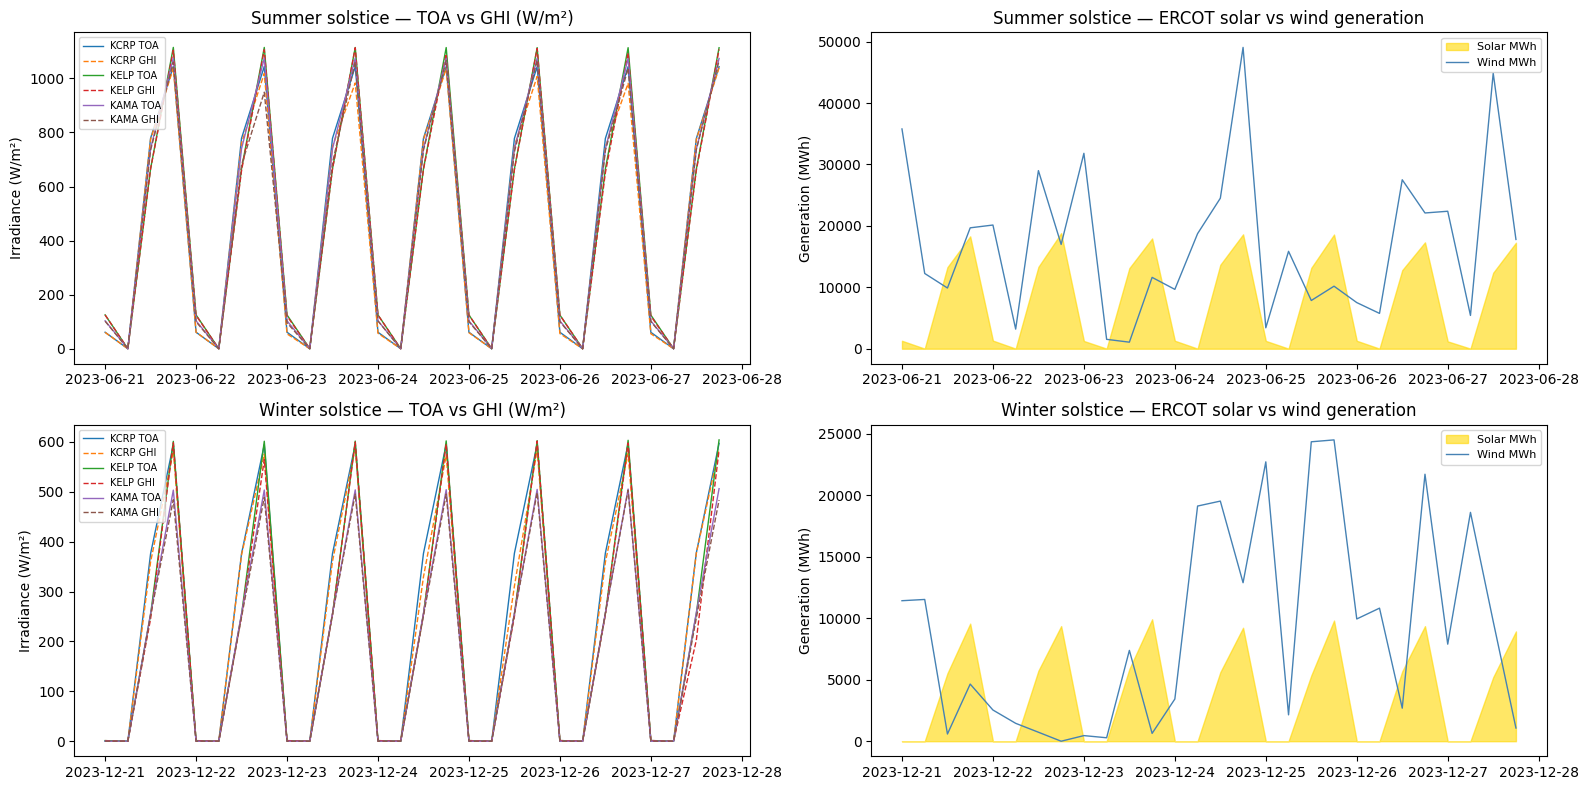

Annual wind generation: 16.4 TWh
Annual solar generation: 8.8 TWh
Wind capacity factor: 37.3%
Solar capacity factor: 35.6% (daylight hours)


In [7]:
from causalts.synthetic_data.weather_datasets import _toa_irradiance, STATION_META
import numpy as np

lats = np.array([STATION_META[s]['lat'] for s in STATIONS])
lons = np.array([STATION_META[s]['lon'] for s in STATIONS])

# Show one summer week and one winter week
summer_start = pd.Timestamp('2023-06-21', tz='UTC')
winter_start = pd.Timestamp('2023-12-21', tz='UTC')

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for row, (season, start) in enumerate([('Summer solstice', summer_start), ('Winter solstice', winter_start)]):
    mask = (df.index >= start) & (df.index < start + pd.Timedelta('7D'))
    t_sub = df.index[mask]
    toa_sub = _toa_irradiance(t_sub, lats, lons)  # (T_sub, 8)
    cloud_sub = df.loc[mask, [f'{s}_cloud' for s in STATIONS]].values  # (T_sub, 8)
    ghi_sub = toa_sub * (1 - 0.75 * (cloud_sub / 100) ** 3.4)

    # TOA for kcrp and kelp
    ax = axes[row, 0]
    for i, s in enumerate(['kcrp', 'kelp', 'kama']):
        si = STATIONS.index(s)
        ax.plot(t_sub, toa_sub[:, si], label=f'{s.upper()} TOA', lw=1)
        ax.plot(t_sub, ghi_sub[:, si], label=f'{s.upper()} GHI', lw=1, ls='--')
    ax.set_title(f'{season} — TOA vs GHI (W/m²)')
    ax.set_ylabel('Irradiance (W/m²)')
    ax.legend(fontsize=7)

    # Total solar generation
    ax = axes[row, 1]
    solar_sub = solar_mwh.loc[mask]
    ax.fill_between(t_sub, solar_sub.values, alpha=0.6, color='gold', label='Solar MWh')
    ax.plot(t_sub, wind_mwh.loc[mask].values, color='steelblue', lw=1, label='Wind MWh')
    ax.set_title(f'{season} — ERCOT solar vs wind generation')
    ax.set_ylabel('Generation (MWh)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Annual wind generation: {wind_mwh.sum()/1e6:.1f} TWh')
print(f'Annual solar generation: {solar_mwh.sum()/1e6:.1f} TWh')
print(f'Wind capacity factor: {wind_mwh.mean()/30_000:.1%}')
print(f'Solar capacity factor: {solar_mwh[solar_mwh>0].mean()/23_000:.1%} (daylight hours)')

## 7. Wind Power Curve

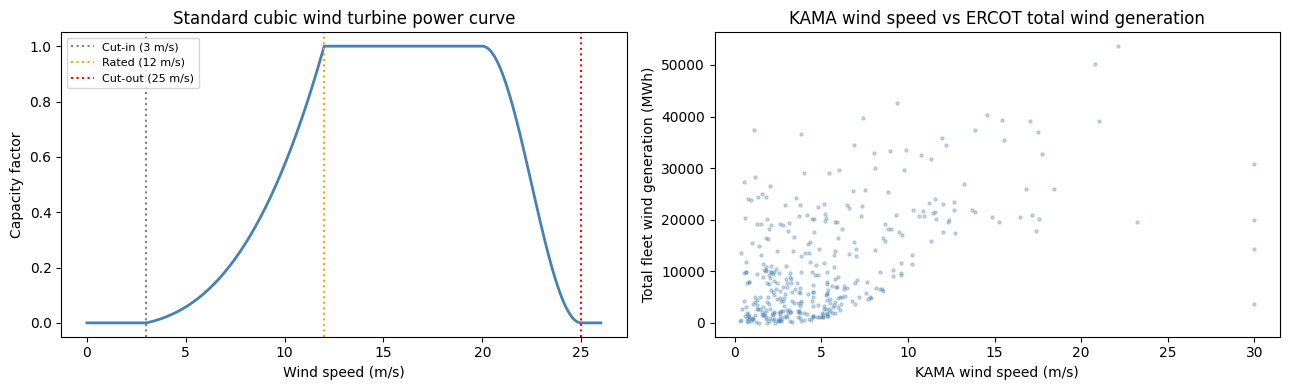

In [8]:
from causalts.synthetic_data.weather_datasets import _power_curve

v = np.linspace(0, 26, 300)
cf = _power_curve(v)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(v, cf, 'steelblue', lw=2)
ax.axvline(3, color='gray', ls=':', label='Cut-in (3 m/s)')
ax.axvline(12, color='orange', ls=':', label='Rated (12 m/s)')
ax.axvline(25, color='red', ls=':', label='Cut-out (25 m/s)')
ax.set_xlabel('Wind speed (m/s)')
ax.set_ylabel('Capacity factor')
ax.set_title('Standard cubic wind turbine power curve')
ax.legend(fontsize=8)

# Scatter: KAMA wind speed vs fleet generation
ax = axes[1]
kama_w = df['kama_wind'].values
ax.scatter(kama_w[::4], wind_mwh.values[::4], alpha=0.3, s=5, color='steelblue')
ax.set_xlabel('KAMA wind speed (m/s)')
ax.set_ylabel('Total fleet wind generation (MWh)')
ax.set_title('KAMA wind speed vs ERCOT total wind generation')

plt.tight_layout()
plt.show()

## 8. Causal Discovery with CDNOTS+

Run CDNOTS+ unconstrained on the 8 wind stations and score it against the
ground truth.

> **Read the headline F1 with care.** The ground truth is dominated by the 16
> self-AR (autoregressive) edges, which any method recovers almost for free.
> They make up most of the score, so a high overall F1 mostly measures
> autoregression, not spatial structure. The 6 cross-station wind→wind edges
> are the part that is actually hard and actually interesting here — the
> second line printed below, and all of §8b, score those in isolation with
> `exclude_self_loops=True`. The gap between the two numbers is the point.

> **On background knowledge.** An earlier version of this notebook added a
> constraint forbidding all contemporaneous (lag-0) wind→wind links, on the
> physical argument that propagation between stations takes at least one
> 6-hour step. That is no longer useful here: CDNOTS+ drops unresolved
> contemporaneous edges anyway, so the constraint buys no precision, and
> restricting the search measurably *cost* recall on the true lagged edges.
> Background knowledge still earns its keep where a direction is genuinely
> ambiguous — see §10, where it forbids the physically impossible
> cloud→wind direction.

In [9]:
import time
from causalts import run_cdnots_plus, run_cdnots
from causalts.ci_tests import PartialCorr
from causalts.cdnots import make_background_knowledge
from causalts.utils import evaluate_graph
from causalts.plotting.compare import compare_graphs

wind_cols    = [f"{s}_wind" for s in STATIONS]
df_wind      = df[wind_cols].copy()
gt_wind_only = ground_truth[::2, ::2, :]  # (8, 8, 3) — wind variables only
wind_labels  = [s.upper() for s in STATIONS]

ci = PartialCorr(data=np.zeros((2, 2)))

# --- CDNOTS+ (unconstrained) ---
t0 = time.time()
_res = run_cdnots_plus(
    df_wind, ci, num_lags=2, include_C=False, alpha=0.05
)
cdnots_time = time.time() - t0

disc_cdnots = _res.cg_tig
m_base = evaluate_graph(disc_cdnots, gt_wind_only)
print(f"CDNOTS+  ({cdnots_time:.1f}s):  "
      f"F1={m_base['F1']:.3f}  Prec={m_base['Precision']:.3f}  "
      f"Rec={m_base['TPR']:.3f}  SHD={m_base['SHD']}")

# Same graph, scored on cross-station edges only — the hard part.
m_base_x = evaluate_graph(disc_cdnots, gt_wind_only, exclude_self_loops=True)
print(f"  cross-station only:  F1={m_base_x['F1']:.3f}  "
      f"Prec={m_base_x['Precision']:.3f}  Rec={m_base_x['TPR']:.3f}  "
      f"SHD={m_base_x['SHD']}")

CDNOTS+  (0.6s):  F1=0.927  Prec=1.000  Rec=0.864  SHD=3
  cross-station only:  F1=0.667  Prec=1.000  Rec=0.500  SHD=3


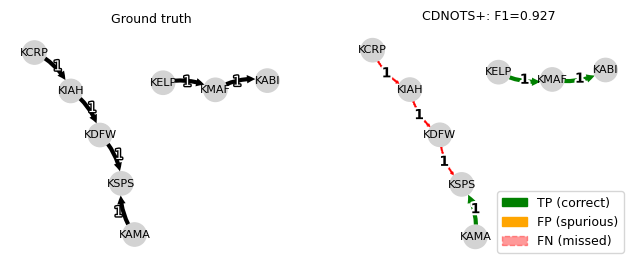

In [10]:
import causalts.plotting as tp
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
tp.plot_graph(gt_wind_only, var_names=wind_labels, fig_ax=(fig, axes[0]), node_label_size=8)
tp.compare_graphs(
    gt_wind_only, _res.cg_tig, var_names=wind_labels,
    figsize=(6, 6), show_legend=True, legend_loc=None,
    arrow_linewidth=3, node_label_size=8, fig_ax=(fig, axes[1])
);
axes[0].set_title(f"Ground truth", fontsize=9);
axes[1].set_title(f"CDNOTS+: F1={m_base['F1']:.3f}", fontsize=9);

## 8b. CEDAR on Wind Stations — scoring the edges that matter

CEDAR uses pairwise lag selection (`partial_dcor`) plus conditional independence
tests — O(d²) tests, versus CDNOTS+'s skeleton expansion. On seasonal/periodic
data `partial_dcor` residualises each target on its own lag-1, which can
suppress some seasonal cross-station signal, so we test both `partial_dcor`
(default) and plain `dcor`.

The important change here is the **metric**, not just the method. Everything
below is scored with `exclude_self_loops=True`, i.e. on the 6 cross-station
spatial edges only. Dropping the 16 free self-AR edges from the score is what
makes the comparison informative: it separates "recovers autoregression" from
"recovers the spatial network".

> **This is not a like-for-like comparison.** CDNOTS+ is run at `alpha=0.05`
> while CEDAR is run at `alpha_cond1 = alpha_cond2 = 0.01`, so the two methods
> are held to different significance thresholds and CDNOTS+ has the more
> permissive one. The ranking below is therefore *not* evidence that one
> algorithm dominates the other — at a matched `alpha=0.01` the ordering
> reverses. Treat these as two configurations that happen to be shown side by
> side, and tune `alpha` per method on your own data before drawing a
> conclusion.

What is worth reading regardless of the ranking is the **per-edge breakdown**:
the two methods miss *different* edges, which is why the union recovers more
true edges than either alone (at some cost in precision).

In [11]:
from causalts.cedar import run_cedar
from causalts.ci_tests import ParCorrGPU

ci_cedar_pdcor = ParCorrGPU(np.zeros((2, 2)), device='cpu')
ci_cedar_dcor  = ParCorrGPU(np.zeros((2, 2)), device='cpu')

t0 = time.time()
res_cedar_pdcor = run_cedar(df_wind, ci_cedar_pdcor, max_lag=2, alpha_cond1=0.01, alpha_cond2=0.01)
t_pdcor = time.time() - t0

t0 = time.time()
res_cedar_dcor  = run_cedar(df_wind, ci_cedar_dcor, max_lag=2, alpha_cond1=0.01, alpha_cond2=0.01,
                           lag_method='dcor')
t_dcor = time.time() - t0

# Cross-variable only (exclude_self_loops=True) for every method.
m_sp_x = evaluate_graph(res_cedar_pdcor.cg_tig, gt_wind_only, exclude_self_loops=True)
m_sd_x = evaluate_graph(res_cedar_dcor.cg_tig,  gt_wind_only, exclude_self_loops=True)

# Union: keep an edge if either CDNOTS+ or CEDAR(dcor) found it
G_union = np.clip(disc_cdnots[:8, :8, :] + res_cedar_dcor.cg_tig[:8, :8, :], 0, 1)
m_union = evaluate_graph(G_union, gt_wind_only, exclude_self_loops=True)

sep = "-" * 66
hdr = f"  {'Algorithm':<30} {'F1':>6} {'Prec':>6} {'Rec':>6} {'SHD':>5}"
print("Cross-variable edges only (exclude_self_loops=True):")
print(sep); print(hdr); print(sep)
print(f"  {'CDNOTS+':<30} {m_base_x['F1']:>6.3f} {m_base_x['Precision']:>6.3f} {m_base_x['TPR']:>6.3f} {m_base_x['SHD']:>5}")
print(f"  {'CEDAR (partial_dcor)':<30} {m_sp_x['F1']:>6.3f} {m_sp_x['Precision']:>6.3f} {m_sp_x['TPR']:>6.3f} {m_sp_x['SHD']:>5}  ({t_pdcor:.1f}s)")
print(f"  {'CEDAR (dcor)':<30} {m_sd_x['F1']:>6.3f} {m_sd_x['Precision']:>6.3f} {m_sd_x['TPR']:>6.3f} {m_sd_x['SHD']:>5}  ({t_dcor:.1f}s)")
print(f"  {'Union (CDNOTS+ + CEDAR dcor)':<30} {m_union['F1']:>6.3f} {m_union['Precision']:>6.3f} {m_union['TPR']:>6.3f} {m_union['SHD']:>5}")
print(sep)

# Per-edge breakdown: show which edges each algorithm finds
gt_cross = gt_wind_only.copy()
for _lag in range(gt_cross.shape[2]):
    np.fill_diagonal(gt_cross[:, :, _lag], 0)
true_edges = [
    (wind_labels[c], wind_labels[e], lag)
    for c in range(8) for e in range(8)
    for lag in range(1, gt_cross.shape[2])
    if gt_cross[c, e, lag]
]
print(f"\nPer-edge breakdown ({len(true_edges)} true cross-variable edges):")
print(f"  {'Edge':<24} {'CDNOTS+':>10} {'CEDAR(dcor)':>12} {'Union':>7}")
print("  " + "-" * 56)
for c, e, lag in true_edges:
    ci_i, ei_i = wind_labels.index(c), wind_labels.index(e)
    found_cd    = bool(disc_cdnots[ci_i, ei_i, lag])
    found_cedar = bool(res_cedar_dcor.cg_tig[ci_i, ei_i, lag])
    found_union = found_cd or found_cedar
    print(f"  {c}(t-{lag})->{e:<10} "
          f"{'✓' if found_cd else '✗':>10}  "
          f"{'✓' if found_cedar else '✗':>11}  "
          f"{'✓' if found_union else '✗':>6}")

Cross-variable edges only (exclude_self_loops=True):
------------------------------------------------------------------
  Algorithm                          F1   Prec    Rec   SHD
------------------------------------------------------------------
  CDNOTS+                         0.667  1.000  0.500     3
  CEDAR (partial_dcor)            0.545  0.600  0.500     5  (1.9s)
  CEDAR (dcor)                    0.545  0.600  0.500     5  (0.1s)
  Union (CDNOTS+ + CEDAR dcor)    0.667  0.667  0.667     4
------------------------------------------------------------------

Per-edge breakdown (6 true cross-variable edges):
  Edge                        CDNOTS+  CEDAR(dcor)   Union
  --------------------------------------------------------
  KCRP(t-1)->KIAH                ✗            ✗       ✗
  KDFW(t-1)->KSPS                ✗            ✓       ✓
  KELP(t-1)->KMAF                ✓            ✗       ✓
  KAMA(t-1)->KSPS                ✓            ✓       ✓
  KIAH(t-1)->KDFW                ✗   

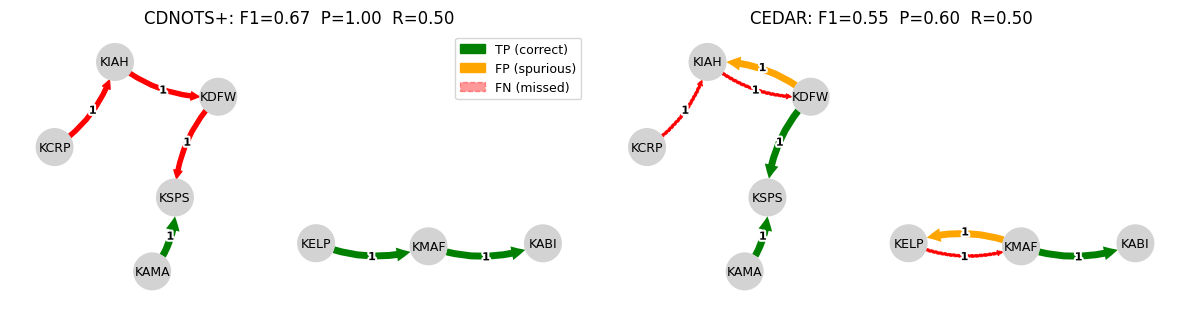

In [12]:
# Geographic node positions (lon/lat → normalized)
lons = np.array([STATION_META[s]["lon"] for s in STATIONS])
lats = np.array([STATION_META[s]["lat"] for s in STATIONS])
lons_n = (lons - lons.mean()) / (lons.max() - lons.min())
lats_n = (lats - lats.mean()) / (lats.max() - lats.min())
scale  = max(np.abs(lons_n).max(), np.abs(lats_n).max())
node_pos = {"x": lons_n / scale, "y": lats_n / scale}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

_, _, pos = compare_graphs(
    gt_wind_only, disc_cdnots,
    var_names=wind_labels, #node_pos=node_pos,
    node_layout="fdp", return_pos=True,
    fig_ax=(fig, ax1), node_size=0.15, arrow_linewidth=5,
    node_label_size=9, link_label_fontsize=8,
    fn_linewidth=3,fn_style="-",legend_loc=None,
    title=f'CDNOTS+: F1={m_base_x["F1"]:.2f}  P={m_base_x["Precision"]:.2f}  R={m_base_x["TPR"]:.2f}',
)
compare_graphs(
    gt_wind_only, res_cedar_dcor.cg_tig,
    var_names=wind_labels, node_pos=pos,
    fig_ax=(fig, ax2), node_size=0.15, arrow_linewidth=5,
    node_label_size=9, link_label_fontsize=8, show_legend=False,
    title=f'CEDAR: F1={m_sd_x["F1"]:.2f}  P={m_sd_x["Precision"]:.2f}  R={m_sd_x["TPR"]:.2f}',
)

plt.tight_layout()
plt.show()

## 9. Temporal Bootstrap: CDNOTS+ vs CEDAR

Run each algorithm on 20 random contiguous windows (~60 % of the year each)
and aggregate edge frequencies into a **persistence matrix**. A single fit
tells you what was found once; persistence tells you what survives resampling,
which is the more honest signal on a year of seasonal data.

The ground truth has two types of edges:
- **16 self-AR edges** (diagonal) — recovered in essentially every window, persistence ≈ 1.0
- **6 spatial cross-station edges** (off-diagonal) — the interesting ones; persistence varies

That split is exactly why the diagonal is worth drawing on the same colour
scale rather than as text: it makes the "free" edges visually separable from
the spatial ones at a glance, and the off-diagonal pattern is what to read.

Comparing the two persistence panels also shows *where* the methods disagree,
rather than just that their scores differ.

temporal_bootstrap:   0%|          | 0/20 [00:00<?, ?run/s]

temporal_bootstrap:   0%|          | 0/20 [00:00<?, ?run/s]

CDNOTS+ bootstrap: 20/20 runs, window = 876 steps (219 days)
CEDAR   bootstrap: 20/20 runs


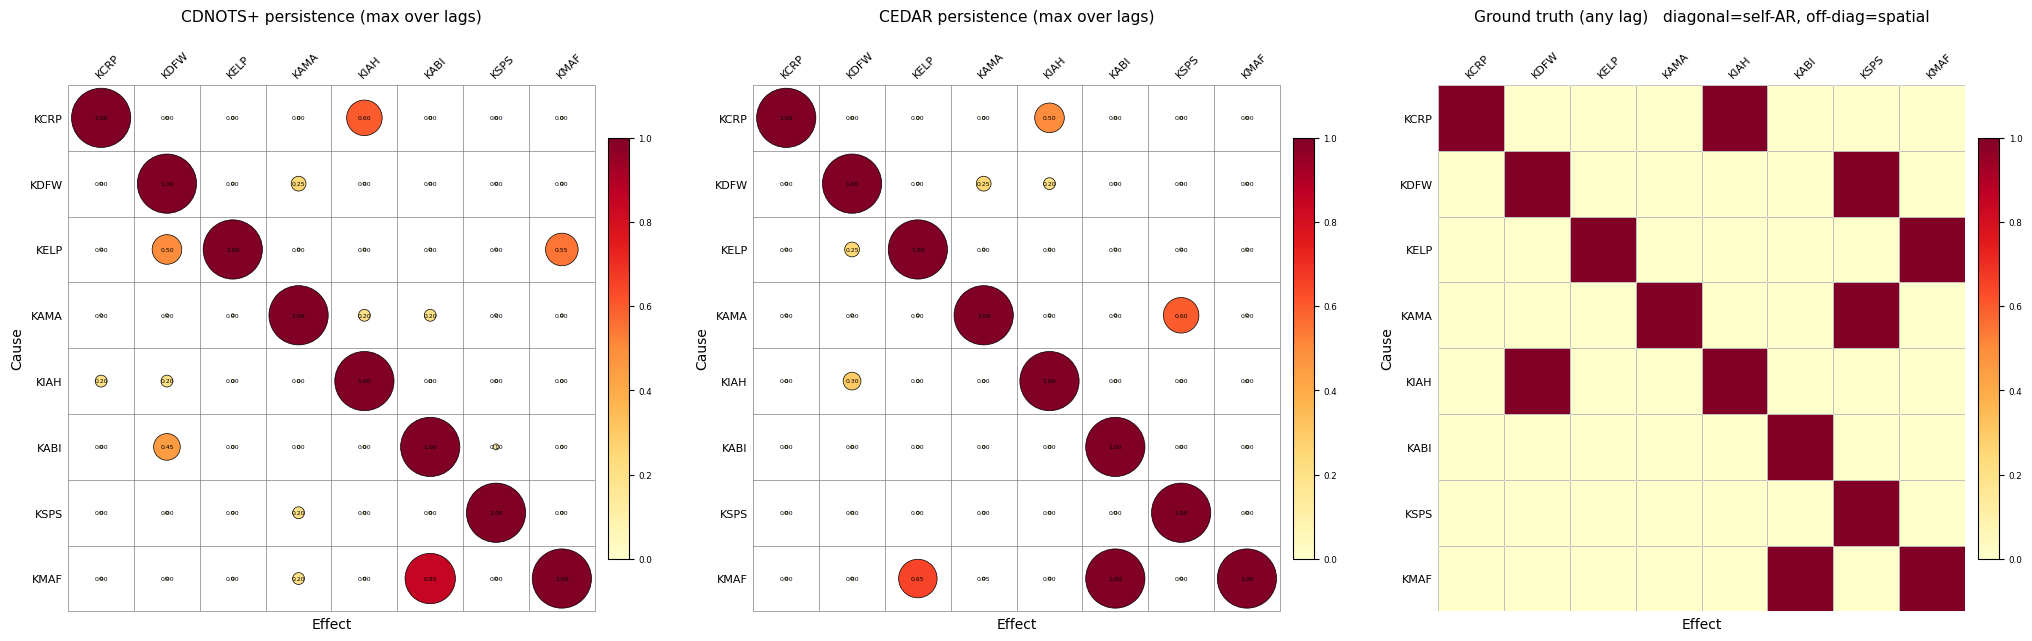

In [13]:
from causalts import temporal_bootstrap

# Each method keeps the alpha it was given in §8 / §8b, so the persistence
# panels are the resampled counterparts of the single fits shown there.
# Note this means the two arms are not on a matched threshold — see the
# caveat in §8b before comparing them to each other.
def _run_cdnots_plus(sub_df):
    _res = run_cdnots_plus(
        sub_df, ci, num_lags=2, include_C=False, alpha=0.05,
    )
    return _res.cg_tig

def _run_cedar(sub_df):
    _ci = ParCorrGPU(np.zeros((2, 2)), device="cpu")
    _res = run_cedar(
        sub_df, _ci, max_lag=2, alpha_cond1=0.01, alpha_cond2=0.01,
        lag_method="dcor",
    )
    return _res.cg_tig

boot = temporal_bootstrap(
    df_wind, _run_cdnots_plus,
    n_bootstrap=20,
    window_frac=0.60,   # ~876 timesteps ≈ 7 months per window
    seed=42,
)
boot_cedar = temporal_bootstrap(
    df_wind, _run_cedar,
    n_bootstrap=20,
    window_frac=0.60,
    seed=42,
)
persist       = boot["persistence"]         # (8, 8, 3)
persist_cedar = boot_cedar["persistence"]   # (8, 8, 3)
print(f"CDNOTS+ bootstrap: {boot['n_success']}/20 runs, "
      f"window = {boot['window_size']} steps ({boot['window_size']*6/24:.0f} days)")
print(f"CEDAR   bootstrap: {boot_cedar['n_success']}/20 runs")

# Max across lags so each (cause, effect) pair has one value
persist_max       = persist.max(axis=2)         # (8, 8)
persist_cedar_max = persist_cedar.max(axis=2)   # (8, 8)
gt_max            = gt_wind_only.max(axis=2)

# All three matrices are directed (cause -> effect) and asymmetric, so each is
# wrapped in a labelled DataFrame — corrplot only treats a bare ndarray as
# precomputed when it happens to be symmetric. diag='glyph' draws the
# diagonal as an ordinary cell, which matters here because the diagonal is
# real data (self-AR), not the trivial 1.0 of a correlation matrix.
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, mat, title in zip(
    axes,
    [persist_max, persist_cedar_max, gt_max.astype(float)],
    ["CDNOTS+ persistence (max over lags)",
     "CEDAR persistence (max over lags)",
     "Ground truth (any lag)   diagonal=self-AR, off-diag=spatial"],
):
    is_gt = mat is not persist_max and mat is not persist_cedar_max
    corrplot(
        pd.DataFrame(mat, index=wind_labels, columns=wind_labels),
        # Persistence is continuous on [0, 1], so circle area meaningfully
        # encodes how often an edge survived resampling. Ground truth is
        # binary, where glyph area would encode nothing.
        method="color" if is_gt else "circle",
        is_corr=False, cmap="YlOrRd", vmin=0.0, vmax=1.0,
        diag="glyph",
        add_coef=not is_gt, number_fmt=".2f", number_cex=0.55,
        tl_cex=0.8, cl_cex=0.7,
        title=title,
        fig_ax=(fig, ax),
    )
    ax.set_xlabel("Effect")
    ax.set_ylabel("Cause")

plt.tight_layout()
plt.show()

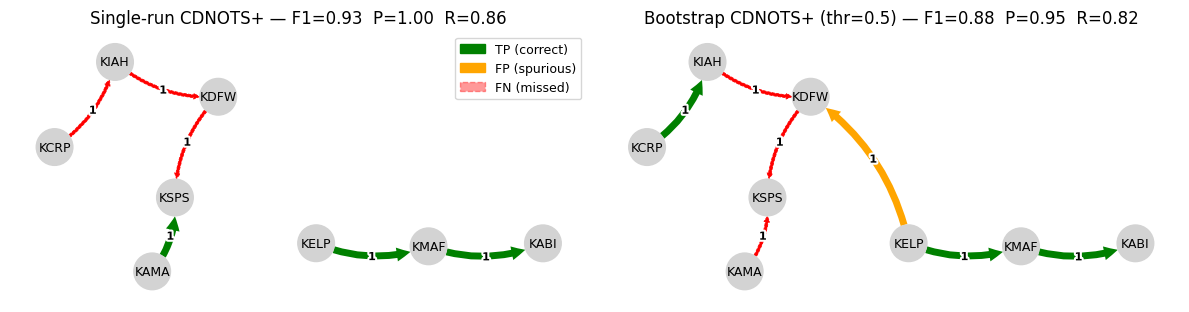

In [14]:
# Threshold chosen from the persistence panel above
THRESHOLD = 0.5
G_boot = (persist >= THRESHOLD).astype(int)
np.fill_diagonal(G_boot[:, :, 0], 0)   # remove self-loops at lag 0

from causalts.utils import evaluate_graph
m_boot  = evaluate_graph(G_boot,    gt_wind_only)
m_base2 = evaluate_graph(disc_cdnots, gt_wind_only)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
compare_graphs(
    gt_wind_only, disc_cdnots,
    var_names=wind_labels, node_pos=pos,
    fig_ax=(fig, ax1), node_size=0.15, arrow_linewidth=5,
    node_label_size=9, link_label_fontsize=8, legend_loc=None,
    title=f'Single-run CDNOTS+ — F1={m_base2["F1"]:.2f}  P={m_base2["Precision"]:.2f}  R={m_base2["TPR"]:.2f}',
)
compare_graphs(
    gt_wind_only, G_boot,
    var_names=wind_labels, node_pos=pos,
    fig_ax=(fig, ax2), node_size=0.15, arrow_linewidth=5,
    node_label_size=9, link_label_fontsize=8, show_legend=False,
    title=f'Bootstrap CDNOTS+ (thr={THRESHOLD}) — F1={m_boot["F1"]:.2f}  P={m_boot["Precision"]:.2f}  R={m_boot["TPR"]:.2f}',
)
plt.tight_layout()
plt.show()

## 10. Full System: Wind + Cloud Cover (Solar Proxy)

The complete dataset has 16 variables: 8 wind speed + 8 cloud cover.
The ground truth includes **contemporaneous wind→cloud edges** (wind speed
determines local cloud cover at the same 6-hour timestep) in addition to
the lagged wind spatial propagation and cloud AR edges.

This is the physically meaningful solar story: wind drives cloud cover, cloud
cover attenuates solar irradiance → solar generation. Recovering the wind→cloud
causal edges is essential for understanding solar variability.

**Challenge:** lag-0 (contemporaneous) edges require the algorithm to orient
undirected correlations. CDNOTS+ Phase 3 uses nonstationarity to orient edges,
but for contemporaneous wind→cloud the seasonal variation must be sufficient
to trigger Phase 3 orientation. We add **physics background knowledge** to
forbid the impossible cloud→wind direction.

Note this is a different use of background knowledge from the one dropped in
§8: there the constraint ruled out a lag that the algorithm already handled,
whereas here it resolves a genuine orientation ambiguity that the data alone
cannot settle.

In [15]:
# Full 16-variable system: wind + cloud
from causalts.cdnots import make_background_knowledge

var_names_full = result['var_names']
d_full = len(var_names_full)
gt_full = result['ground_truth']   # (16, 16, 3)

wind_cols_full  = [f'{s}_wind'  for s in STATIONS]
cloud_cols_full = [f'{s}_cloud' for s in STATIONS]

# Count edges by type
n_ar_wind   = sum(gt_full[i,i,l] for i in range(0,16,2) for l in range(3))   # wind AR
n_ar_cloud  = sum(gt_full[i,i,l] for i in range(1,16,2) for l in range(3))   # cloud AR
n_wc        = sum(gt_full[i,j,0] for i in range(0,16,2) for j in range(1,16,2) if j==i+1)  # wind->cloud
n_spatial   = int(gt_full[::2,::2,:].sum()) - n_ar_wind                         # spatial wind

print(f"Ground truth — 16 variables, {int(gt_full.sum())} total edges:")
print(f"  Wind AR (per-station self-lags)  : {n_ar_wind}")
print(f"  Cloud AR                         : {n_ar_cloud}")
print(f"  Wind→Cloud (contemporaneous)     : {n_wc}  ← solar proxy edges")
print(f"  Spatial wind propagation         : {n_spatial}")
print()

# Baseline: no constraints
ci_full = PartialCorr(data=np.zeros((2, 2)))
t0 = time.time()
res_full_nc = run_cdnots_plus(df, ci_full, num_lags=2, include_C=False, alpha=0.01)
t_nc = time.time() - t0
m_nc = evaluate_graph(res_full_nc.cg_tig[:d_full, :d_full, :], gt_full)

# Physics BK: forbid cloud→wind (physically impossible) and cross-station cloud propagation
forbidden_phys = (
    [(cl, wi, 0, lag) for cl in cloud_cols_full for wi in wind_cols_full for lag in range(3)]
  + [(c1, c2, 0, lag) for c1 in cloud_cols_full for c2 in cloud_cols_full if c1!=c2 for lag in range(1,3)]
)
bk_full = make_background_knowledge(
    var_names=var_names_full, num_lags=2, include_C=False, forbidden=forbidden_phys
)
ci_bk_full = PartialCorr(data=np.zeros((2, 2)))
t0 = time.time()
res_full_bk = run_cdnots_plus(df, ci_bk_full, num_lags=2, include_C=False, alpha=0.01,
                          background_knowledge=bk_full)
t_bk = time.time() - t0
m_bk_full = evaluate_graph(res_full_bk.cg_tig[:d_full, :d_full, :], gt_full)

est_nc = res_full_nc.cg_tig[:d_full, :d_full, :]
est_bk = res_full_bk.cg_tig[:d_full, :d_full, :]

wc_found_nc = sum(1 for s in STATIONS
                  if est_nc[var_names_full.index(f'{s}_wind'), var_names_full.index(f'{s}_cloud'), 0])
wc_found_bk = sum(1 for s in STATIONS
                  if est_bk[var_names_full.index(f'{s}_wind'), var_names_full.index(f'{s}_cloud'), 0])

sep = "-" * 60
hdr = f"  {'Algorithm':<25} {'F1':>6} {'Prec':>6} {'Rec':>6} {'SHD':>5}  {'Wind→Cloud':>11}"
print(sep); print(hdr); print(sep)
print(f"  {'CDNOTS+ (no BK)':<25} {m_nc['F1']:>6.3f} {m_nc['Precision']:>6.3f} {m_nc['TPR']:>6.3f} {m_nc['SHD']:>5}  {wc_found_nc}/8 ({t_nc:.1f}s)")
print(f"  {'CDNOTS+ & physics BK':<25} {m_bk_full['F1']:>6.3f} {m_bk_full['Precision']:>6.3f} {m_bk_full['TPR']:>6.3f} {m_bk_full['SHD']:>5}  {wc_found_bk}/8 ({t_bk:.1f}s)")
print(sep)

Ground truth — 16 variables, 38 total edges:
  Wind AR (per-station self-lags)  : 16
  Cloud AR                         : 8
  Wind→Cloud (contemporaneous)     : 8  ← solar proxy edges
  Spatial wind propagation         : 6

------------------------------------------------------------
  Algorithm                     F1   Prec    Rec   SHD   Wind→Cloud
------------------------------------------------------------
  CDNOTS+ (no BK)            0.781  0.962  0.658    14  0/8 (0.5s)
  CDNOTS+ & physics BK       0.794  1.000  0.658    13  0/8 (0.5s)
------------------------------------------------------------


## Summary

| Feature | Detail |
|---------|--------|
| Stations | 8 ERCOT stations (KCRP, KDFW, KELP, KAMA, KIAH, KABI, KSPS, KMAF) |
| Resolution | 6-hourly, 1 year (1460 steps) |
| Variables | 16 (wind speed + cloud cover per station) |
| Wind model | Weibull(k=2) with log-normal scale VAR(2) — calibrated means, diurnal+seasonal |
| Cloud model | Logit-space AR(1) with contemporaneous wind coupling |
| Solar | Analytical TOA × cloud attenuation → GHI → MW |
| Wind gen | Cubic power curve → capacity factor → MW |
| Ground truth | 38 edges: self-AR + 6 spatial wind + cloud AR + wind→cloud |
| Reproducible | `ercot_weather(seed=42)` |

```python
from causalts.synthetic_data.weather_datasets import ercot_weather
# or:
from causalts.synthetic_data.synthetic_datasets import load_dataset

result = ercot_weather(seed=42)
df = result['df']                         # (1460, 16) 6-hourly DataFrame
ground_truth = result['ground_truth']     # (16, 16, 3) binary causal graph
wind_mwh = result['generation']['wind_mwh']
solar_mwh = result['generation']['solar_mwh']
```